In [2]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/falkodz/TER.git /content/TER
!pip install transformers emoji==0.6.0 -q

import os, shutil
os.makedirs('/content/TER/data', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Colab Notebooks/ChatGPT_final.csv',
            '/content/TER/data/ChatGPT_final.csv')
print("Done ✓")

Mounted at /content/drive
Cloning into '/content/TER'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 76 (delta 35), reused 56 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 4.53 MiB | 12.71 MiB/s, done.
Resolving deltas: 100% (35/35), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Done ✓


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/TER/data/ChatGPT_final.csv',
                 usecols=['Tweet', 'sentiment', 'Date'],
                 low_memory=False)

df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df = df.dropna(subset=['Tweet', 'sentiment', 'Date'])
df = df[df['Tweet'].str.strip() != '']

label2id = {'positive': 0, 'neutral': 1, 'negative': 2}
df['label'] = df['sentiment'].map(label2id)

df['month'] = df['Date'].dt.to_period('M')

print(f"Shape: {df.shape}")
print(f"\nTweets par mois:")
print(df.groupby('month').size())

Shape: (476164, 5)

Tweets par mois:
month
2022-11        77
2022-12     80872
2023-01    105555
2023-02    128459
2023-03    132763
2023-04     28438
Freq: M, dtype: int64


/tmp/ipykernel_6707/2515639976.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['Date'].dt.to_period('M')


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Définir les folds temporels
# Train sur mois 1..n, test sur mois n+1
folds = [
    {'train': ['2022-12'],                              'test': '2023-01'},
    {'train': ['2022-12', '2023-01'],                   'test': '2023-02'},
    {'train': ['2022-12', '2023-01', '2023-02'],        'test': '2023-03'},
    {'train': ['2022-12', '2023-01', '2023-02', '2023-03'], 'test': '2023-04'},
]

results = []

for fold in folds:
    train_months = fold['train']
    test_month = fold['test']

    train_df = df[df['month'].astype(str).isin(train_months)]
    test_df = df[df['month'].astype(str) == test_month]

    # Échantillon pour accélérer
    train_sample = train_df.sample(min(30000, len(train_df)), random_state=42)
    test_sample = test_df.sample(min(10000, len(test_df)), random_state=42)

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=3)
    X_train = tfidf.fit_transform(train_sample['Tweet'])
    X_test = tfidf.transform(test_sample['Tweet'])

    y_train = train_sample['label']
    y_test = test_sample['label']

    # LinearSVC
    svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({
        'train': ' + '.join(train_months),
        'test': test_month,
        'f1_macro': round(f1, 4),
        'train_size': len(train_sample),
        'test_size': len(test_sample)
    })
    print(f"Train: {train_months} → Test: {test_month} | F1: {f1:.4f}")

print("\nDone ✓")

Train: ['2022-12'] → Test: 2023-01 | F1: 0.7478
Train: ['2022-12', '2023-01'] → Test: 2023-02 | F1: 0.7487
Train: ['2022-12', '2023-01', '2023-02'] → Test: 2023-03 | F1: 0.7532
Train: ['2022-12', '2023-01', '2023-02', '2023-03'] → Test: 2023-04 | F1: 0.7736

Done ✓


                                train    test  f1_macro  train_size  test_size
                              2022-12 2023-01    0.7478       30000      10000
                    2022-12 + 2023-01 2023-02    0.7487       30000      10000
          2022-12 + 2023-01 + 2023-02 2023-03    0.7532       30000      10000
2022-12 + 2023-01 + 2023-02 + 2023-03 2023-04    0.7736       30000      10000


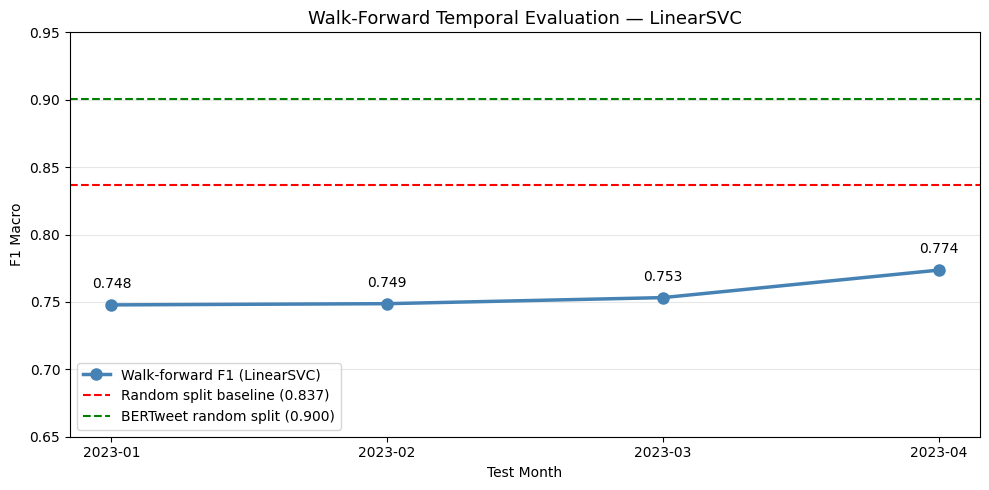

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(results_df['test'], results_df['f1_macro'],
        'o-', color='steelblue', linewidth=2.5, markersize=8, label='Walk-forward F1 (LinearSVC)')
ax.axhline(0.8371, color='red', linestyle='--', linewidth=1.5, label='Random split baseline (0.837)')
ax.axhline(0.9004, color='green', linestyle='--', linewidth=1.5, label='BERTweet random split (0.900)')

for i, row in results_df.iterrows():
    ax.annotate(f"{row['f1_macro']:.3f}",
                xy=(row['test'], row['f1_macro']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10)

ax.set_title('Walk-Forward Temporal Evaluation — LinearSVC', fontsize=13)
ax.set_xlabel('Test Month')
ax.set_ylabel('F1 Macro')
ax.set_ylim(0.65, 0.95)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/TER/figures/11_walkforward_evaluation.png', dpi=150)
plt.show()

In [ ]:
import subprocess
from getpass import getpass

subprocess.run(['git', 'config', 'user.email', 'ton@email.com'], cwd='/content/TER')
subprocess.run(['git', 'config', 'user.name', 'falkodz'], cwd='/content/TER')
subprocess.run(['git', 'add', '.'], cwd='/content/TER')
r = subprocess.run(['git', 'commit', '-m', 'Add walk-forward temporal evaluation notebook'],
                   cwd='/content/TER', capture_output=True, text=True)
print(r.stdout, r.stderr)

token = getpass("Token : ")
result = subprocess.run(
    ['git', 'push', f'https://{token}@github.com/falkodz/TER.git', 'main'],
    cwd='/content/TER', capture_output=True, text=True
)
print(result.stdout, result.stderr)

[main 57f5536] Add walk-forward temporal evaluation notebook
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 figures/11_walkforward_evaluation.png
 
Token : ··········
 To https://github.com/falkodz/TER.git
   5a54bad..57f5536  main -> main



In [3]:
import os
for f in os.listdir('/content/drive/MyDrive/Colab Notebooks/'):
    print(f)

ChatGPT_final.csv
Copie de 05_temporal_analysis (1).ipynb
04_baseline_model.ipynb
05_temporal_analysis.ipynb
Copie de 05_temporal_analysis.ipynb
Copie de 06_bertweet_finetuning.ipynb
06_bertweet_finetuning.ipynb
Copie de 08_lda_topic_modeling.ipynb
Copie de 07_walkforward_evaluation.ipynb
